# Uber Fare Prediction
## Exploratory Data Analysis (EDA)

This notebook performs Exploratory Data Analysis on an Uber fare dataset.

### Objectives

- Understand the structure and characteristics of the dataset.
- Identify and handle missing, duplicate, and invalid data.
- Explore the relationship between `fare_amount` and different trip-related factors.
- Use appropriate visualizations to answer key business questions.
- Extract meaningful insights that can support the next Machine Learning stage.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Dataset Overview

### Loading the Dataset

The dataset is loaded into a Pandas DataFrame for inspection and analysis.

In [3]:
uber_data = pd.read_csv("final_internship_data.csv")

uber_data.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [4]:
uber_data.shape

(500000, 26)

In [5]:
uber_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  str    
 1   User Name          500000 non-null  str    
 2   Driver Name        500000 non-null  str    
 3   Car Condition      500000 non-null  str    
 4   Weather            500000 non-null  str    
 5   Traffic Condition  500000 non-null  str    
 6   key                500000 non-null  str    
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  str    
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  month        

In [6]:
uber_data.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000,499995.000000
mean,11.358361,-1.265712,0.696740,-1.265755,0.696675,1.683428,13.510834,15.684206,6.268650,3.042008,2011.739132,385.279367,380.503657,363.843772,363.674038,355.991423,19.468775,0.297145
std,9.916617,0.206941,0.140909,0.205903,0.128997,1.307395,6.511571,8.681066,3.437815,1.949240,1.860889,2419.087483,2428.804740,2425.075903,2428.348683,2428.730839,367.299601,1.804548
min,-44.900000,-52.119764,-54.389440,-59.049665,-44.676047,0.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341514,32.173712,17.100762,14.886989,7.147384,1.214550,-0.854721
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523163,34.787507,19.591554,18.347580,10.458151,2.116970,-0.050442
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785649,38.304502,22.214815,22.417812,14.448699,3.890070,2.206769
max,500.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


### Initial Observations

The dataset contains Uber ride records with information about:

- Fare amount
- Passenger count
- Pickup and drop-off locations
- Date and time
- Weather condition
- Traffic condition
- Car condition
- Distance
- Distance from major airports

## 2. Data Cleaning

### Checking Missing Values

Missing values are checked to determine whether any records contain incomplete information.

In [7]:
uber_data.isnull().sum()

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

### Handling Missing Values

Only a very small number of records contain missing values. Since the number of affected records is negligible compared with the full dataset, these records are removed.

In [8]:
uber_data = uber_data.dropna()

uber_data.shape

(499995, 26)

### Checking Duplicate Records

Duplicate rows are checked to ensure that the same ride record is not repeated.

In [9]:
uber_data.duplicated().sum()

np.int64(0)

In [10]:
uber_data['key'].duplicated().sum()

np.int64(0)

### Result

No duplicate records or duplicate ride keys were found, so no additional duplicate removal was required.

### Checking Invalid Fare Values

The target variable `fare_amount` should contain positive values. Negative or zero fares are treated as invalid records.

In [11]:
uber_data[uber_data['fare_amount'] <= 0].shape

(35, 26)

In [12]:
uber_data = uber_data[uber_data['fare_amount'] > 0]

uber_data.shape

(499960, 26)

### Checking Passenger Count

A passenger count of zero is not meaningful for an Uber trip, so these records are removed.

In [13]:
uber_data[uber_data['passenger_count'] == 0].shape

(1791, 26)

In [14]:
uber_data['passenger_count'].value_counts().sort_index()

passenger_count
0      1791
1    345983
2     73904
3     21759
4     10613
5     35321
6     10589
Name: count, dtype: int64

In [15]:
uber_data = uber_data[uber_data['passenger_count'] > 0]

uber_data.shape

(498169, 26)

### Checking Invalid Coordinates

Pickup and drop-off coordinates are inspected for invalid zero values.

Records where all four coordinates are zero are considered invalid.

In [16]:
zero_all_coords = (
    (uber_data['pickup_longitude'] == 0) &
    (uber_data['pickup_latitude'] == 0) &
    (uber_data['dropoff_longitude'] == 0) &
    (uber_data['dropoff_latitude'] == 0)
)

zero_all_coords.sum()

np.int64(8968)

In [17]:
uber_data = uber_data[~zero_all_coords]

uber_data.shape

(489201, 26)

Records containing any remaining zero coordinate are also treated as invalid coordinate records.

In [18]:
zero_coords = (
    (uber_data['pickup_longitude'] == 0) |
    (uber_data['pickup_latitude'] == 0) |
    (uber_data['dropoff_longitude'] == 0) |
    (uber_data['dropoff_latitude'] == 0)
)

zero_coords.sum()

np.int64(885)

In [19]:
uber_data = uber_data[~zero_coords]

uber_data.shape

(488316, 26)

### Checking Unrealistic Coordinate Values

The coordinate distributions are inspected to identify records that fall far outside the normal coordinate range observed in the dataset.


In [20]:
uber_data[
    (uber_data['pickup_longitude'] < -1.5) |
    (uber_data['pickup_longitude'] > -1.0) |
    (uber_data['pickup_latitude'] < 0.5) |
    (uber_data['pickup_latitude'] > 1.0)
].shape

(347, 26)

The same validation is applied to both pickup and drop-off coordinates. Records outside the observed valid coordinate ranges are removed.

In [21]:
invalid_coords = (
    (uber_data['pickup_longitude'] < -1.5) |
    (uber_data['pickup_longitude'] > -1.0) |
    (uber_data['pickup_latitude'] < 0.5) |
    (uber_data['pickup_latitude'] > 1.0) |
    (uber_data['dropoff_longitude'] < -1.5) |
    (uber_data['dropoff_longitude'] > -1.0) |
    (uber_data['dropoff_latitude'] < 0.5) |
    (uber_data['dropoff_latitude'] > 1.0)
)

invalid_coords.sum()

np.int64(396)

In [22]:
uber_data = uber_data[~invalid_coords]

uber_data.shape

(487920, 26)

### Checking Trip Distance

Trip distance is inspected for unrealistic values. Extremely large distances are investigated because they may indicate corrupted coordinates.

In [23]:
uber_data['distance'].describe()

count    487920.000000
mean          3.366455
std           5.151410
min           0.000000
25%           1.255784
50%           2.154466
75%           3.928730
max        1669.563418
Name: distance, dtype: float64

In [24]:
uber_data[
    uber_data['distance'] > 100
][['distance', 'fare_amount']].sort_values(
    'distance',
    ascending=False
).head(20)

,distance,fare_amount
453159,1669.563418,9.30
426590,709.847019,7.50
488225,696.278822,8.50
411093,559.425139,4.50
167270,426.899528,14.50
496670,424.833107,3.70
45139,376.445536,57.54
98652,343.669600,10.50
276682,299.712829,6.10
78167,270.597736,4.50


Distances above 100 are treated as unrealistic for this dataset and are removed.

In [25]:
uber_data = uber_data[uber_data['distance'] <= 100]

uber_data.shape

(487821, 26)

Distance values equal to zero are retained when the pickup and drop-off coordinates are identical, because these records may represent very short or same-location trips rather than invalid records.

In [26]:
same_location = (
    (uber_data['pickup_longitude'] == uber_data['dropoff_longitude']) &
    (uber_data['pickup_latitude'] == uber_data['dropoff_latitude'])
)

uber_data[
    (uber_data['distance'] == 0) & same_location
].shape

(5245, 26)

### Checking Extreme Fare Values

Extreme fare values are investigated together with trip distance rather than being removed based only on their magnitude.

Very high fares associated with extremely short distances are treated as suspicious records.

In [27]:
uber_data[
    uber_data['fare_amount'] >= 100
][['fare_amount', 'distance', 'passenger_count']].sort_values(
    'fare_amount',
    ascending=False
).head(20)

,fare_amount,distance,passenger_count
101885,500.00,0.000000,1
287638,450.00,0.001973,1
233874,450.00,0.692212,1
329010,450.00,0.001448,1
361793,400.00,0.001307,1
451974,400.00,0.008944,1
130460,281.05,86.299253,1
309769,263.25,0.015589,2
142550,255.00,0.107639,1
351584,250.00,1.775615,1


In [28]:
uber_data[
    uber_data['fare_amount'] >= 100
][['fare_amount', 'distance', 'passenger_count']].sort_values(
    'fare_amount',
    ascending=False
).head(20)

,fare_amount,distance,passenger_count
101885,500.00,0.000000,1
287638,450.00,0.001973,1
233874,450.00,0.692212,1
329010,450.00,0.001448,1
361793,400.00,0.001307,1
451974,400.00,0.008944,1
130460,281.05,86.299253,1
309769,263.25,0.015589,2
142550,255.00,0.107639,1
351584,250.00,1.775615,1


Records with a fare of at least 100 and a distance below 1 are removed because the combination is highly inconsistent with the general fare-distance relationship observed in the dataset.

In [29]:
uber_data = uber_data[
    ~(
        (uber_data['fare_amount'] >= 100) &
        (uber_data['distance'] < 1)
    )
]

uber_data.shape

(487742, 26)

Other high-fare observations with non-zero or longer distances are retained because high fares can occur on longer trips and should not be removed solely because they are large.

### Final Dataset Check

After cleaning, the dataset is checked again to confirm its final structure and basic statistics.

In [30]:
uber_data.shape

(487742, 26)

In [31]:
uber_data.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000,487742.000000
mean,11.324883,-1.291111,0.711238,-1.291094,0.711245,1.690142,13.512060,15.678361,6.271779,3.041936,2011.737802,41.923811,35.736299,19.626604,18.973168,11.236946,3.333518,0.303945
std,9.568069,0.000764,0.000568,0.000760,0.000623,1.306155,6.508374,8.680763,3.439083,1.948926,1.866163,6.804624,7.582346,6.803292,7.996121,8.086450,3.740643,1.821035
min,0.010000,-1.374014,0.653100,-1.374014,0.651820,1.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141550
25%,6.000000,-1.291409,0.710987,-1.291396,0.710970,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.306930,32.119088,17.038598,14.809368,7.074167,1.255994,-0.878066
50%,8.500000,-1.291231,0.711281,-1.291205,0.711289,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.479329,34.670023,19.495628,18.206369,10.326837,2.154396,-0.099555
75%,12.500000,-1.290991,0.711527,-1.290937,0.711543,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.679664,38.052003,22.022062,22.131017,14.165021,3.927279,2.239452
max,281.050000,-1.226228,0.754226,-1.222612,0.757738,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,990.934710,939.916350,992.227309,957.298626,965.678876,99.876304,3.141593


In [32]:
uber_data.isnull().sum().sum()

np.int64(0)

### Cleaning Summary

The dataset was cleaned by:

- Removing missing records.
- Checking for duplicate records.
- Removing invalid fare values.
- Removing records with zero passengers.
- Removing invalid coordinate records.
- Removing unrealistic trip distances.
- Investigating and removing clearly inconsistent extreme fare-distance combinations.

The cleaned dataset contains approximately **487,742 records**.

# 3. Exploratory Data Analysis

The following questions are investigated using suitable visualizations and supporting statistics.

## Question 1: Does a higher passenger count lead to a higher fare amount?

### Plot Choice

A scatter plot is used because both `passenger_count` and `fare_amount` are numerical variables.

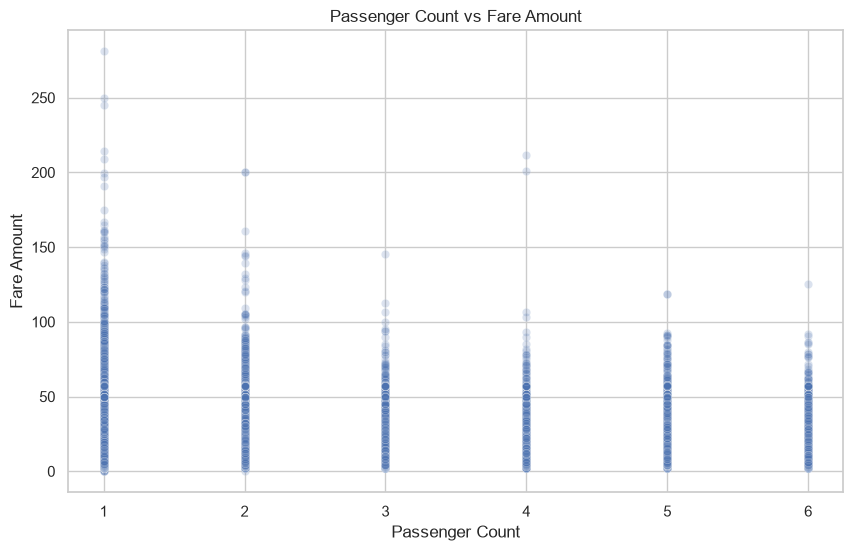

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=uber_data,
    x='passenger_count',
    y='fare_amount',
    alpha=0.2
)

plt.title('Passenger Count vs Fare Amount')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount')

plt.show()

In [34]:
uber_data.groupby('passenger_count')['fare_amount'].agg(
    ['mean', 'median', 'count']
)

,mean,median,count
passenger_count,,,
1,11.181108,8.5,338554
2,11.808396,8.5,72495
3,11.465528,8.5,21330
4,11.718144,8.5,10378
5,11.209965,8.5,34603
6,12.338050,9.0,10382


### Insight

The average fare is relatively similar across passenger counts, and there is no clear increasing trend.

Therefore, passenger count alone does not appear to have a strong relationship with fare amount in this dataset.

## Question 2: Does car condition influence fare amount?

### Plot Choice

A box plot is used because `Car Condition` is categorical while `fare_amount` is numerical. The box plot allows comparison of the fare distributions across car conditions.

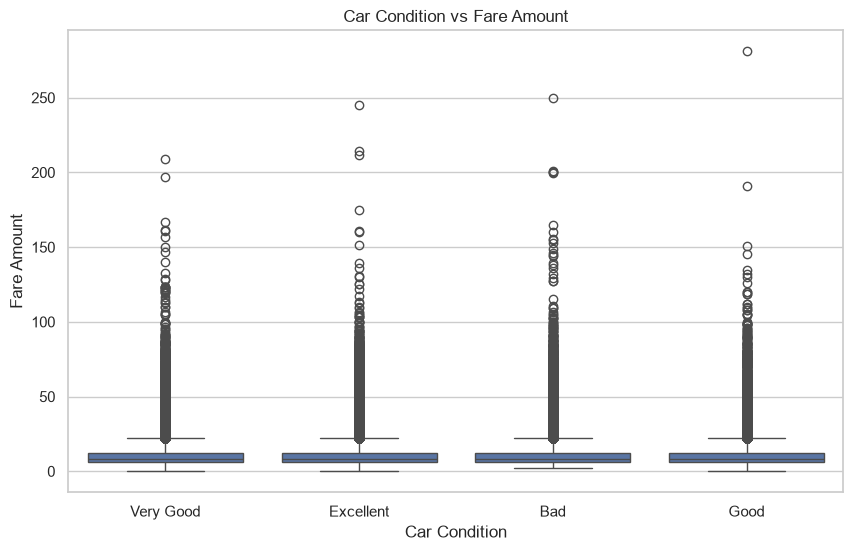

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=uber_data,
    x='Car Condition',
    y='fare_amount'
)

plt.title('Car Condition vs Fare Amount')
plt.xlabel('Car Condition')
plt.ylabel('Fare Amount')

plt.show()

In [36]:
uber_data.groupby('Car Condition')['fare_amount'].agg(
    ['mean', 'median', 'count']
)

,mean,median,count
Car Condition,,,
Bad,11.288206,8.5,121958
Excellent,11.317007,8.5,121712
Good,11.312422,8.5,121893
Very Good,11.381773,8.5,122179


### Insight

The average and median fares are very similar across the different car conditions.

This suggests that car condition does not show a strong apparent relationship with fare amount in this dataset.

## Question 3: At what hour of the day are fares typically highest?

### Plot Choice

A line plot is used because the hours of the day have a natural chronological order. The average fare is calculated for each hour.

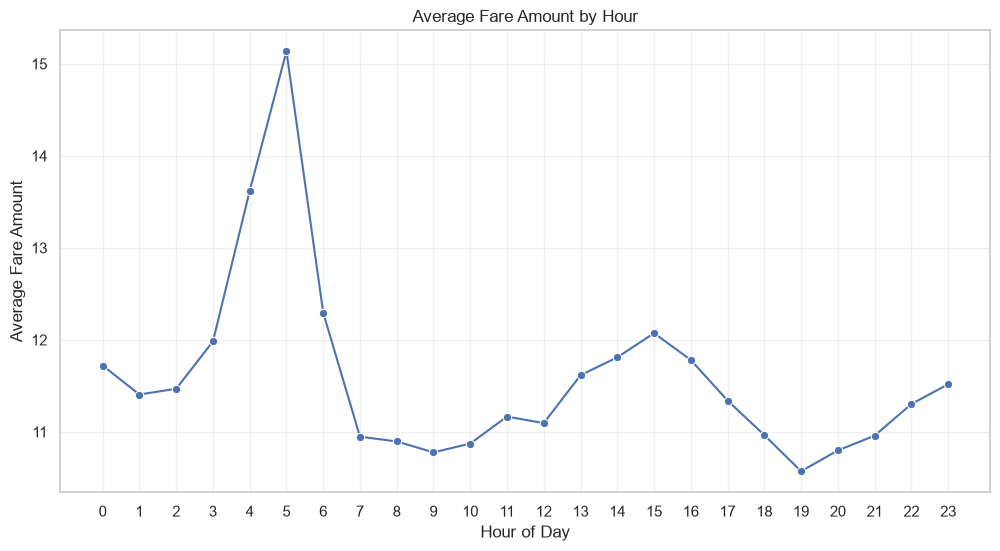

In [37]:
hourly_fare = uber_data.groupby('hour')['fare_amount'].mean()

plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_fare.index,
    y=hourly_fare.values,
    marker='o'
)

plt.title('Average Fare Amount by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Amount')
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

In [38]:
hourly_fare

hour
0     11.721135
1     11.405714
2     11.468765
3     11.982808
4     13.619042
5     15.136249
6     12.294795
7     10.947305
8     10.895985
9     10.777197
10    10.872851
11    11.166067
12    11.094981
13    11.615765
14    11.809651
15    12.072720
16    11.781480
17    11.339831
18    10.964973
19    10.571735
20    10.798054
21    10.958805
22    11.302372
23    11.517551
Name: fare_amount, dtype: float64

### Insight

The highest average fare occurs around **5 AM**, followed by 4 AM and 6 AM.

The lowest average fare occurs around **7 PM**.

This indicates that average fare varies across the day, with higher average fares during the early morning hours in this dataset.

## Question 4: Does traffic condition affect trip fare?

### Plot Choice

A box plot is used because `Traffic Condition` is categorical and `fare_amount` is numerical. This allows the fare distributions to be compared across traffic conditions.

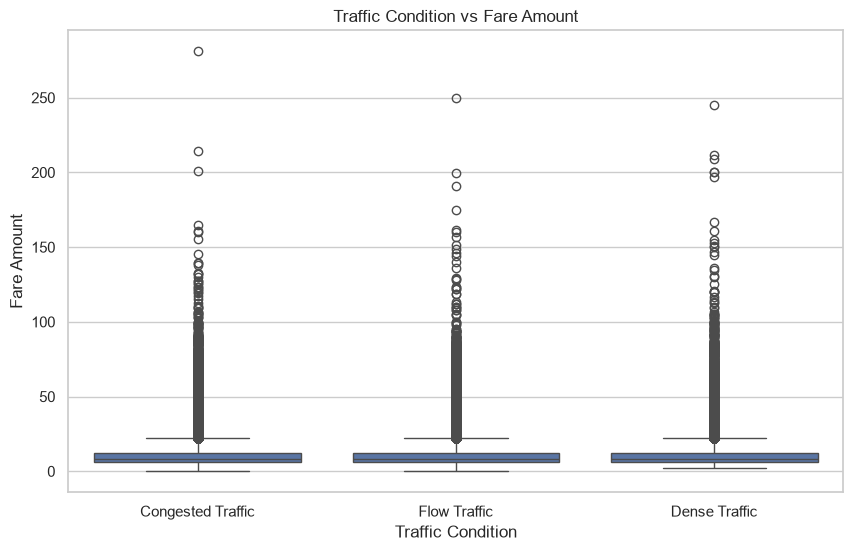

In [39]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=uber_data,
    x='Traffic Condition',
    y='fare_amount'
)

plt.title('Traffic Condition vs Fare Amount')
plt.xlabel('Traffic Condition')
plt.ylabel('Fare Amount')

plt.show()

In [40]:
uber_data.groupby('Traffic Condition')['fare_amount'].agg(
    ['mean', 'median', 'count']
)

,mean,median,count
Traffic Condition,,,
Congested Traffic,11.353038,8.5,162806
Dense Traffic,11.324899,8.5,162473
Flow Traffic,11.296654,8.5,162463


### Insight

The average fares are very close across the three traffic conditions, and the median fare is the same.

Therefore, traffic condition alone does not show a strong apparent relationship with fare amount in this dataset.

## Question 5: Is trip distance the strongest predictor of fare amount?

### Plot Choice

A scatter plot is used because both `distance` and `fare_amount` are numerical variables. Pearson correlation is also calculated to measure the strength of their linear relationship.

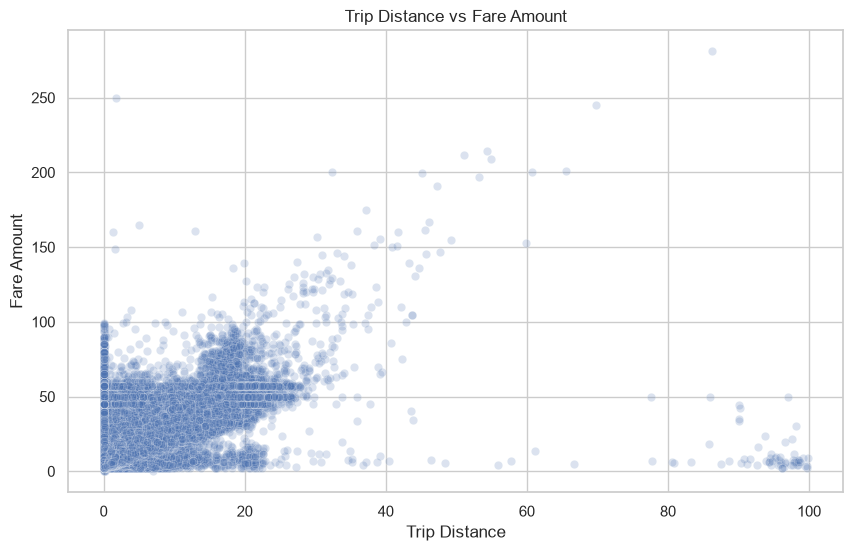

In [41]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=uber_data,
    x='distance',
    y='fare_amount',
    alpha=0.2
)

plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')

plt.show()

In [42]:
uber_data['distance'].corr(uber_data['fare_amount'])

np.float64(0.8375250871782265)

In [43]:
numeric_corr = (
    uber_data
    .select_dtypes(include='number')
    .corr()['fare_amount']
    .sort_values(ascending=False)
)

numeric_corr

fare_amount          1.000000
distance             0.837525
pickup_longitude     0.333828
nyc_dist             0.296062
ewr_dist             0.283391
dropoff_longitude    0.257821
sol_dist             0.251249
year                 0.118963
lga_dist             0.069581
month                0.025359
passenger_count      0.014762
weekday              0.003539
day                  0.001899
hour                -0.019540
bearing             -0.024131
dropoff_latitude    -0.147690
pickup_latitude     -0.179675
jfk_dist            -0.305204
Name: fare_amount, dtype: float64

### Insight

The correlation between trip distance and fare amount is approximately **0.838**, indicating a strong positive linear relationship.

Among the numerical variables examined, `distance` has the highest positive correlation with `fare_amount`.

Therefore, within this correlation-based EDA, trip distance is the strongest linear indicator of fare amount.

> Correlation measures association and does not by itself prove causation or guarantee that distance will be the strongest feature in a Machine Learning model.

## Question 6: At what time of day are ride requests most frequent?

### Plot Choice

A bar chart is used to compare the number of ride requests across the 24 hours of the day.

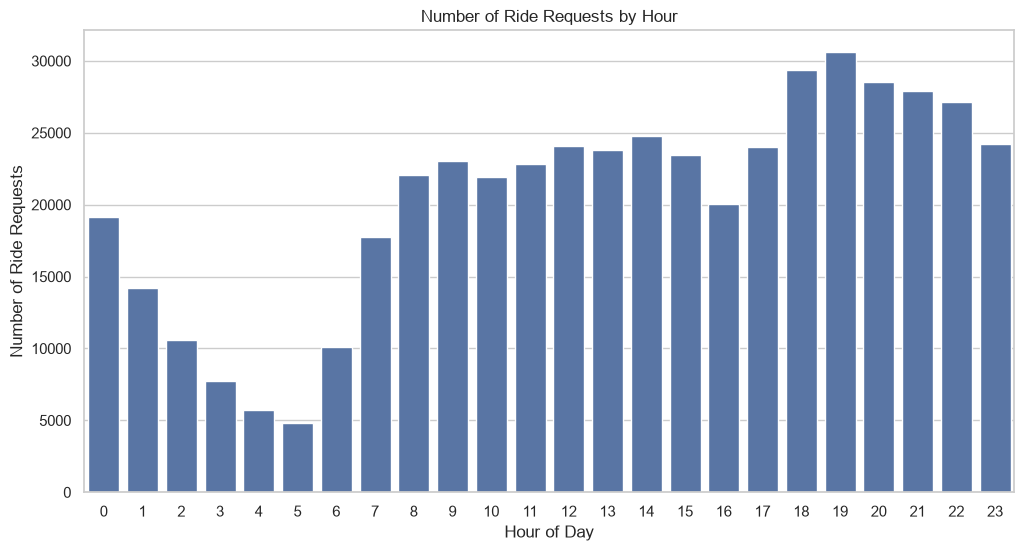

In [44]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=uber_data,
    x='hour'
)

plt.title('Number of Ride Requests by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Ride Requests')

plt.show()

In [45]:
uber_data['hour'].value_counts().sort_index()

hour
0     19124
1     14185
2     10605
3      7721
4      5698
5      4834
6     10084
7     17775
8     22067
9     23039
10    21900
11    22797
12    24049
13    23795
14    24799
15    23464
16    20076
17    24039
18    29342
19    30602
20    28509
21    27892
22    27116
23    24230
Name: count, dtype: int64

### Insight

Ride requests are most frequent during the evening hours.

The highest number of requests occurs at **7 PM**, with more than 30,000 rides.

The lowest number of requests occurs around **5 AM**.

Overall, the dataset shows substantially higher ride activity during the evening compared with the early morning hours.

## Question 7: Does weather condition influence average trip distance?

### Plot Choice

A box plot is used to compare the distribution of trip distances across different weather conditions.

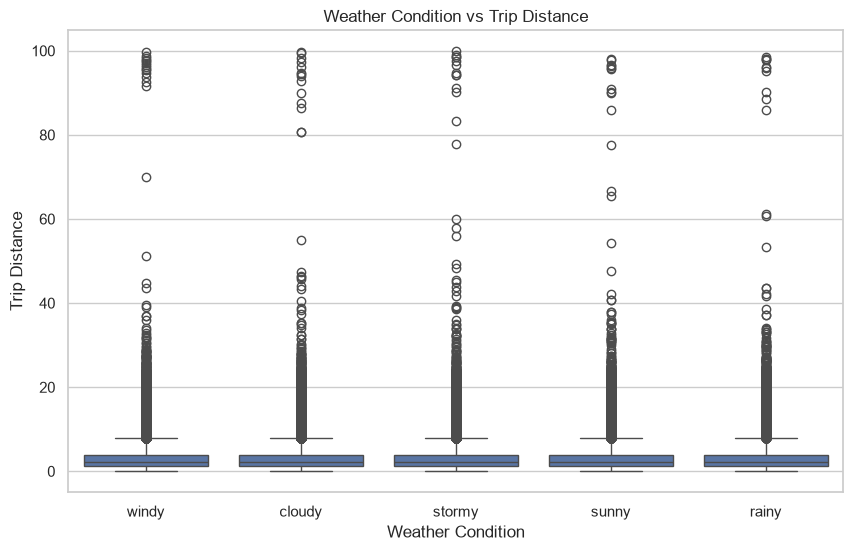

In [46]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=uber_data,
    x='Weather',
    y='distance'
)

plt.title('Weather Condition vs Trip Distance')
plt.xlabel('Weather Condition')
plt.ylabel('Trip Distance')

plt.show()

In [47]:
uber_data.groupby('Weather')['distance'].agg(
    ['mean', 'median', 'count']
)

,mean,median,count
Weather,,,
cloudy,3.330090,2.136294,97556
rainy,3.328135,2.164387,97579
stormy,3.334977,2.154860,97551
sunny,3.342581,2.159262,97923
windy,3.331765,2.157841,97133


### Insight

The average trip distances are very similar across all weather conditions.

The differences between cloudy, rainy, stormy, sunny, and windy conditions are small.

Therefore, weather condition does not appear to have a strong influence on average trip distance in this dataset.

## Question 8: Are rides that start closer to airports generally more expensive?

### Approach

The dataset contains distances to three airports:

- JFK
- EWR
- LGA

For each ride, the minimum of these three distances is used as an approximation of the distance to the nearest airport.

### Plot Choice

A scatter plot is used to examine the relationship between distance to the nearest airport and fare amount.

In [48]:
nearest_airport_dist = uber_data[
    ['jfk_dist', 'ewr_dist', 'lga_dist']
].min(axis=1)

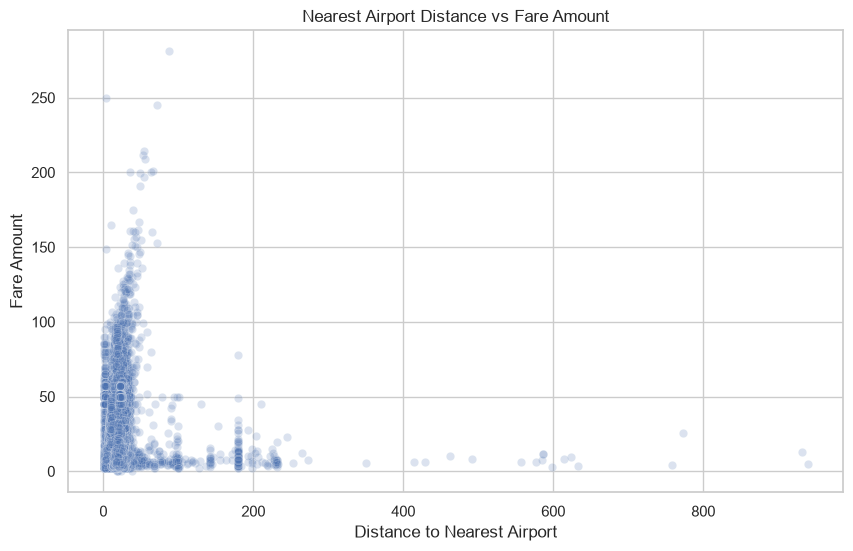

In [49]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=nearest_airport_dist,
    y=uber_data['fare_amount'],
    alpha=0.2
)

plt.title('Nearest Airport Distance vs Fare Amount')
plt.xlabel('Distance to Nearest Airport')
plt.ylabel('Fare Amount')

plt.show()

In [50]:
nearest_airport_dist.corr(uber_data['fare_amount'])

np.float64(-0.03054796498610938)

### Insight

The Pearson correlation is approximately **-0.031**, which is very close to zero.

This indicates that there is no clear linear relationship between distance to the nearest airport and fare amount in this dataset.

Therefore, being closer to an airport does not appear to be associated with substantially higher fares based on this analysis.

## Q9 — How Is the Fare Amount Distributed?

**Question:**  
How is the Fare Amount distributed across the dataset?

**Plot Choice:**  
Histogram

**Why:**  
A histogram is suitable for examining the distribution of a numerical variable. It helps us understand the most common fare ranges, the spread of the data, and the presence of extreme values.

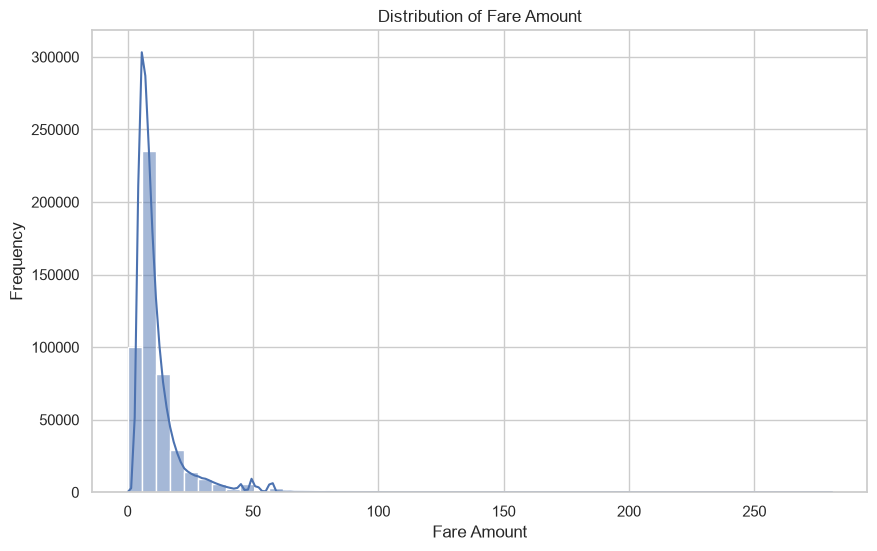

In [51]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=uber_data,
    x='fare_amount',
    bins=50,
    kde=True
)

plt.title('Distribution of Fare Amount')
plt.xlabel('Fare Amount')
plt.ylabel('Frequency')
plt.show()

In [52]:
print("Fare Amount Statistics")
print("----------------------")

print("Count:", uber_data['fare_amount'].count())
print("Mean:", uber_data['fare_amount'].mean())
print("Median:", uber_data['fare_amount'].median())
print("Minimum:", uber_data['fare_amount'].min())
print("Maximum:", uber_data['fare_amount'].max())

print("\nQuantiles")
print("---------")

print(uber_data['fare_amount'].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]))

print("\nStandard Deviation:", uber_data['fare_amount'].std())

print("\nFare Ranges")
print("-----------")

print("0 - 5:", ((uber_data['fare_amount'] >= 0) & (uber_data['fare_amount'] < 5)).sum())
print("5 - 10:", ((uber_data['fare_amount'] >= 5) & (uber_data['fare_amount'] < 10)).sum())
print("10 - 20:", ((uber_data['fare_amount'] >= 10) & (uber_data['fare_amount'] < 20)).sum())
print("20 - 50:", ((uber_data['fare_amount'] >= 20) & (uber_data['fare_amount'] < 50)).sum())
print("50 - 100:", ((uber_data['fare_amount'] >= 50) & (uber_data['fare_amount'] < 100)).sum())
print("100+:", (uber_data['fare_amount'] >= 100).sum())

Fare Amount Statistics
----------------------
Count: 487742
Mean: 11.324883442475736
Median: 8.5
Minimum: 0.01
Maximum: 281.05

Quantiles
---------
0.25     6.00
0.50     8.50
0.75    12.50
0.90    20.50
0.95    30.33
0.99    52.00
Name: fare_amount, dtype: float64

Standard Deviation: 9.568068731761866

Fare Ranges
-----------
0 - 5: 66537
5 - 10: 231158
10 - 20: 138568
20 - 50: 45307
50 - 100: 6052
100+: 120


### Interpretation

The Fare Amount distribution is right-skewed, with most trips concentrated in the lower fare ranges.

The median fare is **$8.50**, while the mean fare is approximately **$11.32**, indicating that higher fares increase the average.

Most rides have fares below **$20**, while only a small number of trips have very high fares. The maximum fare in the cleaned dataset is **$281.05**.

Overall, the target variable is not normally distributed and contains a relatively small number of high-fare observations that may require attention during the modeling stage.

## Q10 — Which Numerical Features Have the Strongest Relationship with Fare Amount?

**Question:**  
Which numerical features have the strongest relationship with Fare Amount?

**Plot Choice:**  
Correlation Heatmap

**Why:**  
A correlation heatmap is suitable for examining the linear relationships between numerical features. It helps identify which features have stronger or weaker correlations with Fare Amount and with each other.

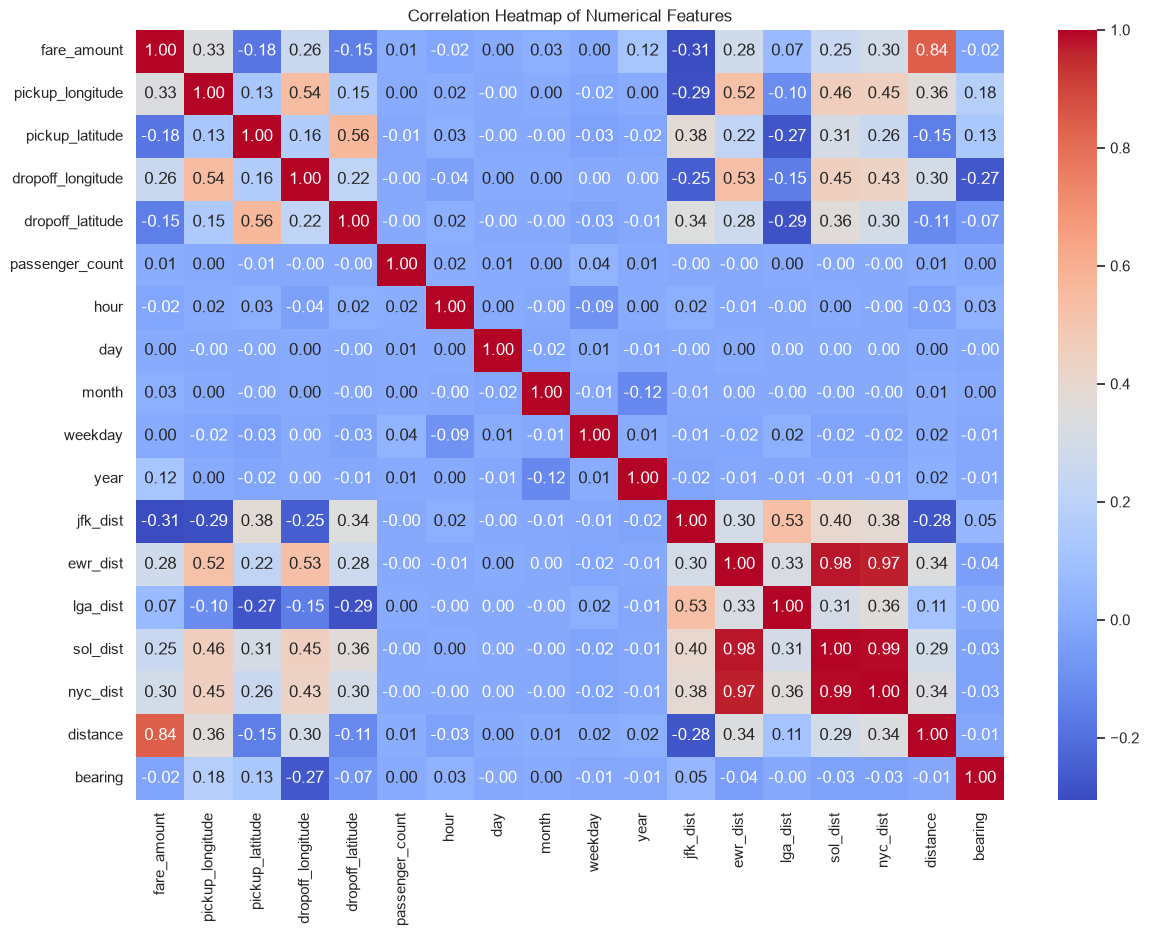

In [53]:
plt.figure(figsize=(14, 10))

numeric_data = uber_data.select_dtypes(include='number')

correlation = numeric_data.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [54]:
fare_correlation = (
    uber_data
    .select_dtypes(include='number')
    .corr()['fare_amount']
    .sort_values(ascending=False)
)

print("Correlation with Fare Amount")
print("----------------------------")
print(fare_correlation)

Correlation with Fare Amount
----------------------------
fare_amount          1.000000
distance             0.837525
pickup_longitude     0.333828
nyc_dist             0.296062
ewr_dist             0.283391
dropoff_longitude    0.257821
sol_dist             0.251249
year                 0.118963
lga_dist             0.069581
month                0.025359
passenger_count      0.014762
weekday              0.003539
day                  0.001899
hour                -0.019540
bearing             -0.024131
dropoff_latitude    -0.147690
pickup_latitude     -0.179675
jfk_dist            -0.305204
Name: fare_amount, dtype: float64


### Interpretation

The results show that **Distance** has the strongest positive correlation with Fare Amount, with a correlation coefficient of approximately **0.84**.

Other numerical features have considerably weaker correlations with Fare Amount. For example, Passenger Count, Hour, Weekday, and Day have correlations close to zero.

This indicates that trip distance has a strong linear relationship with fare amount in the dataset.

However, correlation only measures linear association and does not imply causation. It also does not by itself determine which features will perform best in the final machine learning model.

## Q11 — At What Hours and on Which Days of the Week Are Ride Requests Most Frequent?

**Question:**  
At what hours and on which days of the week are ride requests most frequent?

**Plot Choice:**  
Pivot Heatmap

**Why:**  
A pivot heatmap is suitable for analyzing ride demand across two categorical or discrete variables simultaneously. It allows us to compare the number of rides for each hour of the day across different days of the week.

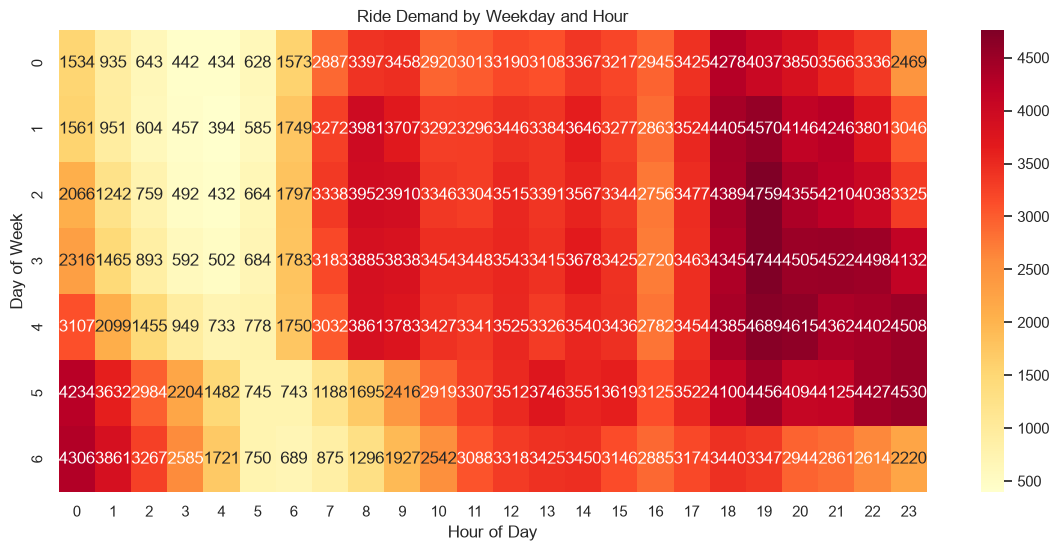

In [55]:
ride_demand = pd.crosstab(
    uber_data['weekday'],
    uber_data['hour']
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    ride_demand,
    annot=True,
    fmt='d',
    cmap='YlOrRd'
)

plt.title('Ride Demand by Weekday and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

In [56]:
highest_demand = (
    ride_demand
    .stack()
    .sort_values(ascending=False)
    .head(10)
)

lowest_demand = (
    ride_demand
    .stack()
    .sort_values()
    .head(10)
)

print("Highest Ride Demand")
print("-------------------")
print(highest_demand)

print("\nLowest Ride Demand")
print("------------------")
print(lowest_demand)

Highest Ride Demand
-------------------
weekday  hour
2        19      4759
3        19      4744
4        19      4689
         20      4615
1        19      4570
5        23      4530
3        21      4522
4        23      4508
3        20      4505
         22      4498
dtype: int64

Lowest Ride Demand
------------------
weekday  hour
1        4       394
2        4       432
0        4       434
         3       442
1        3       457
2        3       492
3        4       502
1        5       585
3        3       592
1        2       604
dtype: int64


### Interpretation

Ride demand is generally higher during the evening hours, particularly between **7 PM and 11 PM**.

The highest individual demand occurs around **7 PM**, while the lowest demand is concentrated during the early morning hours, especially between **2 AM and 5 AM**.

This pattern suggests that the time of day has a noticeable relationship with ride request frequency, with evening hours being considerably busier than the early morning period.

The `weekday` values represent the days of the week, where **0 = Monday** and **6 = Sunday**.

# 4. Key Findings

The main findings from the Exploratory Data Analysis are:

1. **Passenger Count:** No clear increasing relationship was observed between passenger count and fare amount.

2. **Car Condition:** Fare distributions and average fares were very similar across different car conditions.

3. **Time and Fare:** The highest average fare occurred around 5 AM, while lower average fares were observed during the evening hours.

4. **Traffic Condition:** Traffic condition showed little difference in average or median fare.

5. **Trip Distance:** Distance had a strong positive correlation with fare amount (approximately 0.838) and was the strongest positive linear indicator among the numerical variables examined.

6. **Ride Requests by Hour:** The highest number of ride requests occurred around 7 PM, while demand was lowest during the early morning hours.

7. **Weather:** Average trip distance was very similar across different weather conditions.

8. **Airport Distance:** Distance to the nearest airport had almost no linear correlation with fare amount (approximately -0.031).

9. **Fare Distribution:** Most fares were concentrated below $20, with a median fare of $8.50 and a mean fare of approximately $11.32. The distribution was right-skewed due to a smaller number of higher-fare trips.

10. **Numerical Feature Correlation:** Distance showed the strongest positive linear relationship with fare amount among the numerical features examined, while passenger count, hour, weekday, and day showed very weak linear correlations.

11. **Ride Demand by Weekday and Hour:** Ride demand was generally highest during evening hours, particularly between 7 PM and 11 PM, while the lowest demand occurred during the early morning hours.

# 5. Conclusion

The Exploratory Data Analysis provided a clear understanding of the factors associated with Uber fare amounts and ride activity.

The strongest observed linear relationship with `fare_amount` was `distance`, with a correlation of approximately 0.838. In contrast, passenger count, car condition, traffic condition, weather, and airport distance showed relatively weak relationships with fare amount or trip distance.

The analysis also revealed important temporal patterns. Average fares were highest during the early morning hours, particularly around 5 AM, while ride-request activity was highest during the evening, especially around 7 PM.

The Fare Amount distribution was right-skewed, with most trips having fares below $20. The analysis also showed that ride demand varies across both hours and days of the week.

Overall, the EDA identified the main patterns, relationships, and data characteristics that should be considered when preparing the features and selecting models for the next stage.

The cleaned dataset is now ready for the next stage of the project: **Machine Learning model development and fare prediction**.